In [1]:
# ── Imports ────────────────────────────────────────────────────────────────

# PyTorch core — the deep learning framework
import torch
import torch.nn as nn                  # Neural network layers (Linear, Conv2d, etc.)
import torch.optim as optim            # Optimizers (SGD, Adam, etc.)
from torch.utils.data import DataLoader  # Batches images for training

# torchvision — PyTorch's computer vision library
import torchvision.transforms as transforms   # Image preprocessing pipeline
import torchvision.datasets as datasets       # ImageFolder: loads images from folders
import torchvision.models as models           # Pretrained models (ResNet, VGG, etc.)

# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
import os                              # File path handling

# Confirm GPU availability (MBP likely CPU-only, that's fine for this dataset)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0


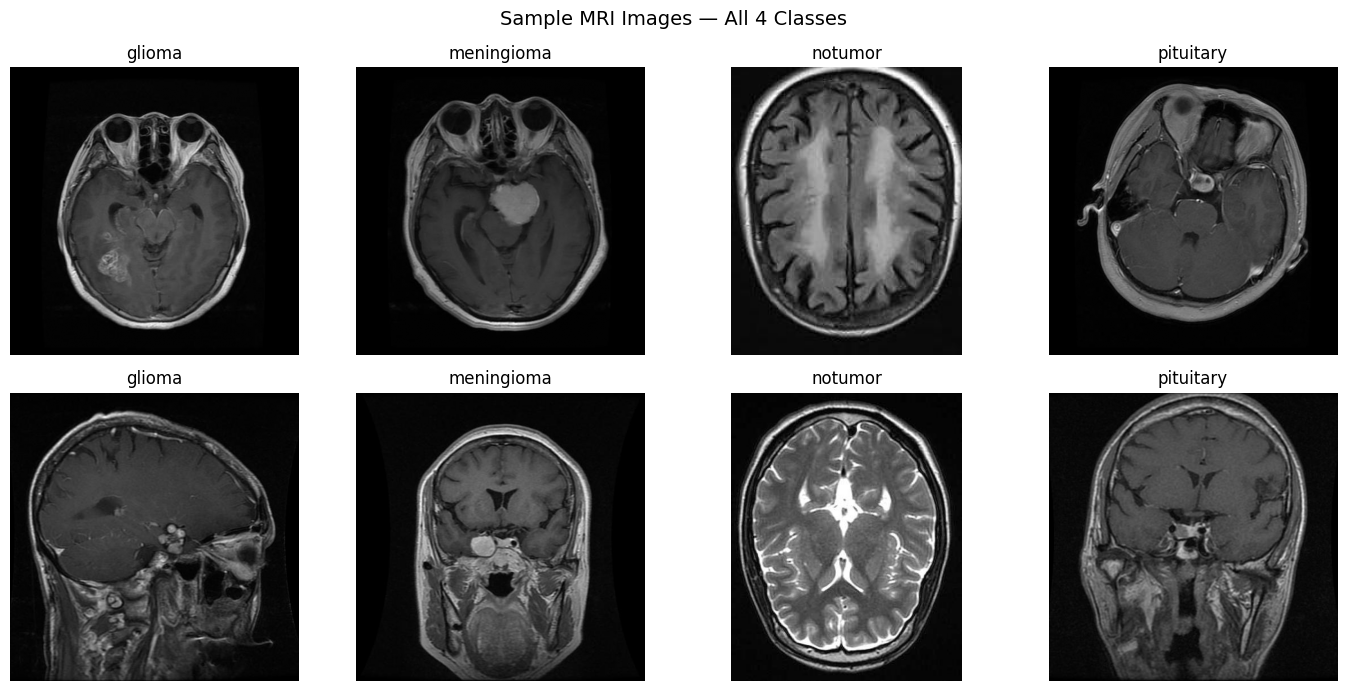

FileNotFoundError: [Errno 2] No such file or directory: '/Users/vchike-okeke/brain-tumor-mri/Training/glioma/Tr-pi_766.jpg'

In [2]:
# ── Visualize Sample MRI Images ────────────────────────────────────────────
# Before building any model, always look at your data.
# This tells you: image quality, color vs grayscale, typical size, class variety.

from PIL import Image  # Pillow — loads image files into Python

# Path to the training data
data_dir = os.path.expanduser("~/brain-tumor-mri")

# The 4 classes we're classifying
classes = ["glioma", "meningioma", "notumor", "pituitary"]

# Set up a 2x4 grid of subplots (2 rows, 4 columns — one column per class)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample MRI Images — All 4 Classes", fontsize=14)

for col, class_name in enumerate(classes):
    # Get the folder path for this class
    class_folder = os.path.join(data_dir, "Training", class_name)
    
    # List all image files in the folder
    image_files = os.listdir(class_folder)
    
    # Show 2 different sample images per class
    for row in range(2):
        img_path = os.path.join(class_folder, image_files[row])
        
        # Open image with Pillow
        img = Image.open(img_path)
        
        # Display it in the grid
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")  # Hide axis ticks

plt.tight_layout()
plt.show()

# Also print image size so we know what we're dealing with
sample_img = Image.open(os.path.join(data_dir, "Training", "glioma", image_files[0]))
print(f"Sample image size: {sample_img.size}")   # (width, height)
print(f"Sample image mode: {sample_img.mode}")   # RGB or L (grayscale)

In [3]:
# Check image size — load from glioma folder specifically
glioma_folder = os.path.join(data_dir, "Training", "glioma")
glioma_files = os.listdir(glioma_folder)

sample_img = Image.open(os.path.join(glioma_folder, glioma_files[0]))
print(f"Sample image size: {sample_img.size}")   # (width, height)
print(f"Sample image mode: {sample_img.mode}")   # RGB or grayscale

Sample image size: (512, 512)
Sample image mode: L


In [4]:
# ── Image Transforms (Preprocessing) ───────────────────────────────────────
# ResNet-18 was trained on 224x224 RGB images.
# Our MRI scans are 512x512 grayscale.
# We need to resize, convert to 3 channels, and normalize.

# Training transforms — includes data augmentation
# Augmentation = artificially creates variation so the model generalizes better
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # Resize from 512x512 → 224x224 (ResNet input size)
    transforms.Grayscale(num_output_channels=3),  # Convert L (1ch) → RGB (3ch) by copying the channel 3x
    transforms.RandomHorizontalFlip(),   # Randomly flip image left-right (augmentation)
    transforms.RandomRotation(10),       # Randomly rotate up to 10 degrees (augmentation)
    transforms.ToTensor(),               # Convert PIL image → PyTorch tensor (values 0.0–1.0)
    transforms.Normalize(                # Normalize using ImageNet mean/std
        mean=[0.485, 0.456, 0.406],      # These are the exact values ResNet was trained with
        std=[0.229, 0.224, 0.225]        # Keeps our input in the same scale ResNet expects
    )
])

# Test transforms — NO augmentation (we want consistent evaluation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined.")
print(f"Train pipeline: {len(train_transforms.transforms)} steps")
print(f"Test pipeline:  {len(test_transforms.transforms)} steps")

Transforms defined.
Train pipeline: 6 steps
Test pipeline:  4 steps


In [5]:
# ── Load Dataset with ImageFolder ──────────────────────────────────────────
# ImageFolder automatically assigns class labels based on folder names.
# Folder structure: brain-tumor-mri/Training/glioma/*.jpg → label = "glioma"
# No manual labeling needed — the folder structure IS the label.

train_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "Training"),  # Points to the Training folder
    transform=train_transforms                 # Applies our preprocessing pipeline
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "Testing"),   # Points to the Testing folder
    transform=test_transforms
)

# DataLoader batches images so we don't load all 5,600 into memory at once
# batch_size=32: process 32 images at a time during training
# shuffle=True: randomize order each epoch so model doesn't learn order patterns
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Verify everything loaded correctly
print(f"Training images : {len(train_dataset)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Classes         : {train_dataset.classes}")
print(f"Class → index   : {train_dataset.class_to_idx}")
print(f"Training batches: {len(train_loader)}")

Training images : 5600
Test images     : 1600
Classes         : ['glioma', 'meningioma', 'notumor', 'pituitary']
Class → index   : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training batches: 175


In [6]:
# ── Load Pretrained ResNet-18 and Adapt for 4-Class MRI ────────────────────

# Load ResNet-18 pretrained on ImageNet (downloads weights automatically first time)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# ResNet-18 architecture ends with a fully connected layer: 512 → 1000 classes
# (ImageNet has 1,000 classes — we only have 4)
# We replace just that final layer to output 4 classes instead of 1,000

# First, check what the original final layer looks like
print(f"Original final layer: {model.fc}")

# Replace it with a new Linear layer: 512 inputs → 4 outputs
# This new layer has RANDOM weights — everything else keeps ImageNet weights
model.fc = nn.Linear(in_features=512, out_features=4)

print(f"New final layer    : {model.fc}")

# Move model to device (CPU in our case)
model = model.to(device)

# Count total trainable parameters so we know model size
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/vchike-okeke/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|███████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 113MB/s]

Original final layer: Linear(in_features=512, out_features=1000, bias=True)
New final layer    : Linear(in_features=512, out_features=4, bias=True)
Trainable parameters: 11,178,564


In [7]:
# ── Loss Function and Optimizer ─────────────────────────────────────────────

# Loss function: CrossEntropyLoss
# Standard choice for multi-class classification (4 classes here)
# Measures how wrong the model's predictions are — lower = better
# Combines softmax (converts raw outputs to probabilities) + log loss internally
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam
# Adjusts model weights after each batch to reduce the loss
# lr (learning rate) = how big each weight update step is
# Small lr = slow but stable; large lr = fast but can overshoot
# 0.0001 is standard for fine-tuning pretrained models
# (lower than training from scratch because weights are already good)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print(f"Learning rate : {optimizer.param_groups[0]['lr']}")

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.0001


In [8]:
# ── Training Loop ───────────────────────────────────────────────────────────

# Number of epochs = how many times we pass through the entire training set
# 5 epochs is a good starting point for fine-tuning on this dataset size
num_epochs = 5

# Track loss and accuracy each epoch so we can plot learning curves after
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    
    # Set model to training mode — enables dropout and batch normalization updates
    model.train()
    
    running_loss = 0.0      # Accumulates loss across all batches this epoch
    correct = 0             # Count of correct predictions this epoch
    total = 0               # Total images processed this epoch
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # images: tensor of shape [32, 3, 224, 224] — batch of 32 images
        # labels: tensor of shape [32] — correct class index for each image
        
        # Move data to device (CPU here)
        images = images.to(device)
        labels = labels.to(device)
        
        # ── Forward pass ──
        # Feed images through the network → get raw scores for each class
        outputs = model(images)          # Shape: [32, 4] — 4 class scores per image
        
        # Compute how wrong the predictions are vs the true labels
        loss = criterion(outputs, labels)
        
        # ── Backward pass ──
        optimizer.zero_grad()   # Clear gradients from previous batch (MUST do this every batch)
        loss.backward()         # Compute gradients (how much each weight contributed to the loss)
        optimizer.step()        # Update weights using the gradients
        
        # ── Track metrics ──
        running_loss += loss.item()
        
        # Get predicted class = index with highest score
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Compute epoch-level metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total * 100
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete.")

Epoch [1/5] | Loss: 0.2385 | Accuracy: 91.70%
Epoch [2/5] | Loss: 0.0906 | Accuracy: 96.88%
Epoch [3/5] | Loss: 0.0555 | Accuracy: 98.27%
Epoch [4/5] | Loss: 0.0342 | Accuracy: 98.89%
Epoch [5/5] | Loss: 0.0308 | Accuracy: 99.04%

Training complete.


In [10]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'], check=True)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.90      0.99      0.94       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



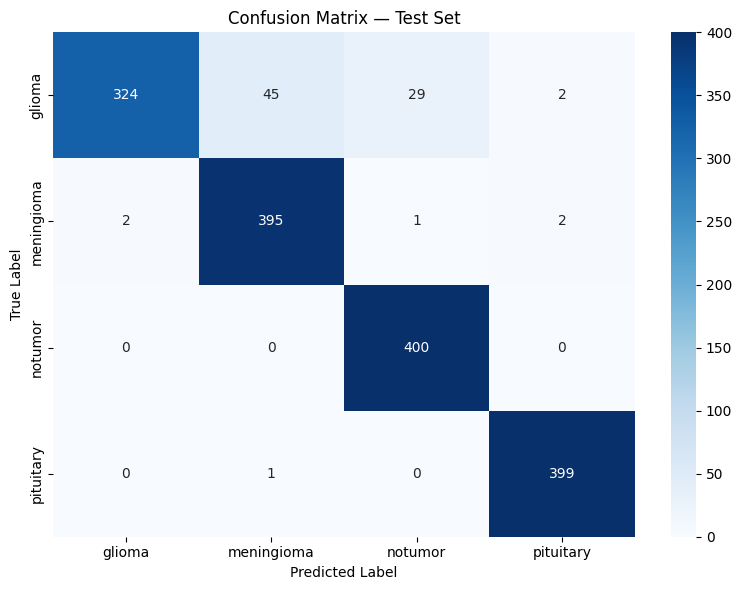

ROC-AUC (one-vs-rest): 0.9897


In [11]:
# ── Evaluate on Test Set ────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Set model to evaluation mode
# Disables dropout and freezes batch normalization — model behaves deterministically
model.eval()

all_preds   = []   # Predicted class indices
all_labels  = []   # True class indices
all_probs   = []   # Raw probability scores for each class (needed for AUC)

# torch.no_grad() tells PyTorch not to compute gradients during evaluation
# We're not updating weights — saves memory and speeds things up
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass — get raw class scores
        outputs = model(images)
        
        # Convert raw scores → probabilities using softmax
        # softmax ensures all 4 class probabilities sum to 1.0
        probs = torch.softmax(outputs, dim=1)
        
        # Get predicted class = index with highest probability
        _, predicted = torch.max(outputs, dim=1)
        
        # Store results (move to CPU and convert to numpy for sklearn)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert lists to numpy arrays
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Classification Report ──
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ── AUC (one-vs-rest for multiclass) ──
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print(f"ROC-AUC (one-vs-rest): {auc:.4f}")

In [12]:
# ── Save the Trained Model ──────────────────────────────────────────────────
# torch.save() saves the model weights to disk as a .pth file
# Without this, the trained weights live only in memory and are lost when
# the kernel restarts or the notebook closes

save_path = os.path.expanduser("~/brain-tumor-mri/mri_resnet18.pth")

# state_dict() returns a dictionary of all layer names → weight tensors
# This is the standard way to save PyTorch models (saves weights only, not architecture)
torch.save(model.state_dict(), save_path)

print(f"Model saved to: {save_path}")

Model saved to: /Users/vchike-okeke/brain-tumor-mri/mri_resnet18.pth


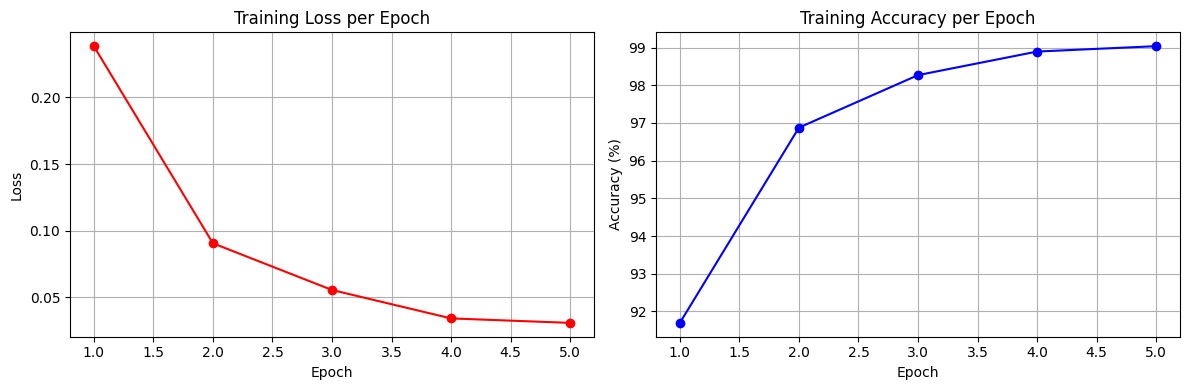

In [13]:
# ── Plot Learning Curves ────────────────────────────────────────────────────
# Learning curves show how loss and accuracy changed across epochs
# Good training: loss goes down, accuracy goes up, both smoothly

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(range(1, num_epochs+1), train_losses, marker='o', color='red')
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Accuracy curve
ax2.plot(range(1, num_epochs+1), train_accuracies, marker='o', color='blue')
ax2.set_title("Training Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)

plt.tight_layout()
plt.show()